# Análisis Exploratorio de Fraude en Transacciones con Tarjetas de Crédito
## Grupo 8 - Alabarca Yarlenis, Villarreal Antoine, Otero Felix, Jean

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("credit_card_fraud_10k.csv")

| Feature Name | Descripción |
|---|---|
| `transaction_id` | Identificador único para cada transacción |
| `amount` | Monto de la transacción |
| `transaction_hour` | Hora de la transacción (0–23) |
| `merchant_category` | Tipo de comercio |
| `foreign_transaction` | Indica si la transacción es internacional (0/1) |
| `location_mismatch` | Diferencia entre la ubicación de facturación y la ubicación de la transacción (0/1) |
| `device_trust_score` | Puntaje de confianza del dispositivo (0–100) |
| `velocity_last_24h` | Número de transacciones realizadas en las últimas 24 horas |
| `cardholder_age` | Edad del titular de la tarjeta |

In [3]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='str')

In [5]:
df.shape

(10000, 10)

### Estructura de Datos

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [7]:
df.dtypes

transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category          str
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object

In [8]:
df.nunique()

transaction_id         10000
amount                  8788
transaction_hour          24
merchant_category          5
foreign_transaction        2
location_mismatch          2
device_trust_score        75
velocity_last_24h         10
cardholder_age            52
is_fraud                   2
dtype: int64

### buscar duplicados

In [9]:
# buscar duplicados
df.duplicated().sum()

np.int64(0)

In [10]:
# verificar si el identificador de transaccion se duplica
df["transaction_id"].duplicated().sum()

np.int64(0)

### Datos Faltantes

In [11]:
# Datos faltantes
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

## Variable Objetivo

In [12]:
df["is_fraud"].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [13]:
df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64

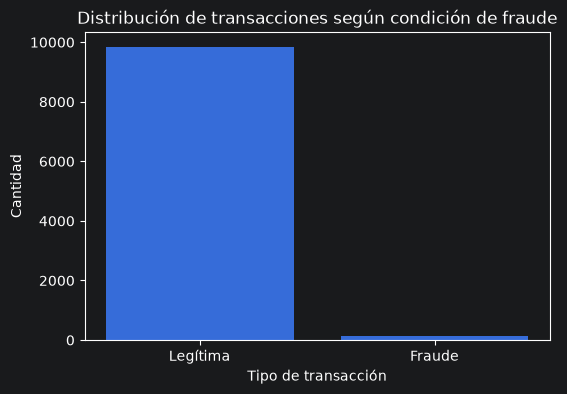

In [14]:

conteos = df["is_fraud"].value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ["Legítima", "Fraude"],
    conteos.values
)

plt.title("Distribución de transacciones según condición de fraude")
plt.xlabel("Tipo de transacción")
plt.ylabel("Cantidad")

plt.show()

In [15]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [16]:
variables_resumen = [
    "is_fraud",
    "device_trust_score",
    "velocity_last_24h",
    "amount"
]

tabla_descriptiva = df[variables_resumen].agg([
    "mean",
    "median",
    "min",
    "max"
]).T

tabla_descriptiva

,mean,median,min,max
is_fraud,0.015100,0.000,0.0,1.00
device_trust_score,61.798900,62.000,25.0,99.00
velocity_last_24h,2.008900,2.000,0.0,9.00
amount,175.949849,122.095,0.0,1471.04


In [17]:
df.groupby("is_fraud")["device_trust_score"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
is_fraud,,,,,
0,9849,62.165804,62.0,25,99
1,151,37.867550,32.0,25,99


In [18]:
df.groupby("is_fraud")["velocity_last_24h"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
is_fraud,,,,,
0,9849,1.990557,2.0,0,9
1,151,3.205298,3.0,0,7


In [19]:
df.groupby("is_fraud")["amount"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
is_fraud,,,,,
0,9849,175.333015,122.11,0.00,1471.04
1,151,216.182980,118.94,0.11,1185.07


### Hipotesis 1. Las transacciones fraudulentas presentan un menor device_trust_score y una mayor velocity_last_24h que las transacciones legítima

In [20]:
fraude_comercio = (
    df.groupby("merchant_category")["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_comercio["tasa_fraude_%"] = (
    fraude_comercio["tasa_fraude"] * 100
)

fraude_comercio = fraude_comercio.sort_values(
    "tasa_fraude_%",
    ascending=False
)

fraude_comercio

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
merchant_category,,,,
Grocery,1944,39,0.020062,2.006173
Food,2093,35,0.016722,1.672241
Travel,1990,29,0.014573,1.457286
Electronics,1923,24,0.012480,1.248050
Clothing,2050,24,0.011707,1.170732


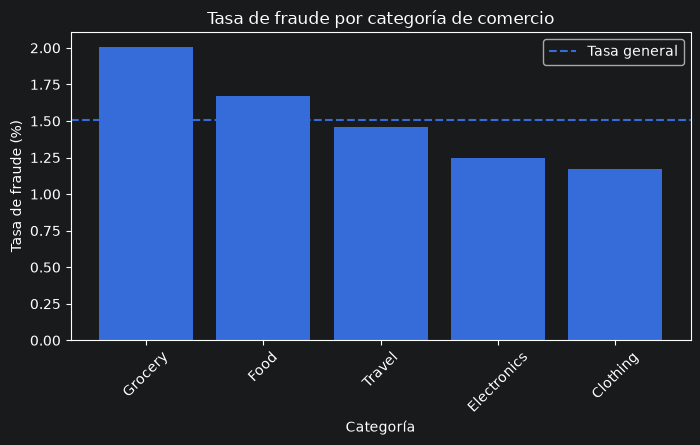

In [34]:
tasa_base = df["is_fraud"].mean() * 100

plt.figure(figsize=(8, 4))

plt.bar(
    fraude_comercio.index,
    fraude_comercio["tasa_fraude_%"]
)

plt.axhline(tasa_base,
    linestyle="--",
    label="Tasa general"
)

plt.title("Tasa de fraude por categoría de comercio")
plt.xlabel("Categoría")
plt.ylabel("Tasa de fraude (%)")
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [21]:
fraude_hora = (
    df.groupby("transaction_hour")["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_hora["tasa_fraude_%"] = (
    fraude_hora["tasa_fraude"] * 100
)

fraude_hora

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
transaction_hour,,,,
0,417,37,0.088729,8.872902
1,425,34,0.080000,8.000000
2,385,23,0.059740,5.974026
3,425,27,0.063529,6.352941
4,384,1,0.002604,0.260417
5,419,2,0.004773,0.477327
6,413,2,0.004843,0.484262
7,425,0,0.000000,0.000000
8,424,3,0.007075,0.707547


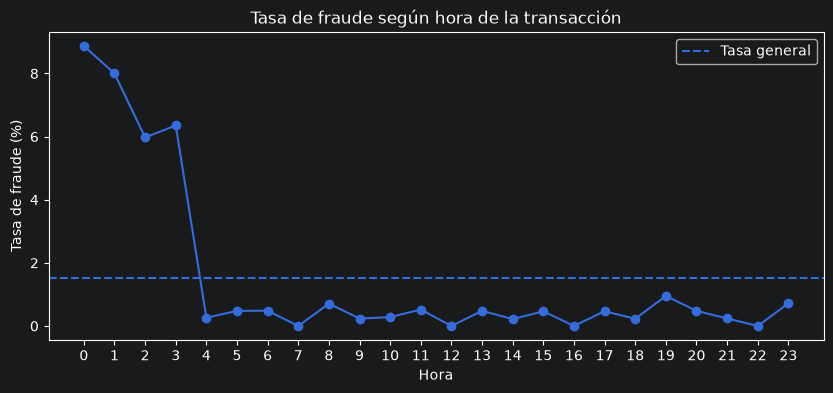

In [35]:
plt.figure(figsize=(10, 4))

plt.plot(
    fraude_hora.index,
    fraude_hora["tasa_fraude_%"],
    marker="o"
)

plt.axhline(
    tasa_base,
    linestyle="--",
    label="Tasa general"
)

plt.title("Tasa de fraude según hora de la transacción")
plt.xlabel("Hora")
plt.ylabel("Tasa de fraude (%)")
plt.xticks(range(24))
plt.legend()

plt.show()

### Hispotesis 2 Las transacciones realizadas entre las 00:00 y las 03:59 presentan una mayor tasa de fraude que las transacciones realizadas durante el resto del día.

In [22]:
fraude_internacional = (
    df.groupby("foreign_transaction")["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_internacional["tasa_fraude_%"] = (
    fraude_internacional["tasa_fraude"] * 100
)

fraude_internacional

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
foreign_transaction,,,,
0,9022,69,0.007648,0.764797
1,978,82,0.083845,8.384458


### Hipotesis 3. Las transacciones internacionales presentan una mayor tasa de fraude que las transacciones no internacionales.

In [29]:
fraude_ubicacion = (
    df.groupby("location_mismatch")["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_ubicacion["tasa_fraude_%"] = (
    fraude_ubicacion["tasa_fraude"] * 100
)

fraude_ubicacion

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
location_mismatch,,,,
0,9143,79,0.008640,0.864049
1,857,72,0.084014,8.401400


### Hipotesis 4 Las transacciones cuya ubicación no coincide con la ubicación de facturación presentan una mayor tasa de fraude que aquellas sin discrepancia de ubicación.

In [33]:
df["age_group"] = pd.cut(
    df["cardholder_age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=[
        "Menor de 25",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65 o más"
    ]
)

fraude_edad = (
    df.groupby("age_group", observed=False)["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_edad["tasa_fraude_%"] = (
    fraude_edad["tasa_fraude"] * 100
)

fraude_edad

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
age_group,,,,
Menor de 25,1536,20,0.013021,1.302083
25-34,1937,31,0.016004,1.600413
35-44,1915,35,0.018277,1.827676
45-54,1943,27,0.013896,1.389604
55-64,1930,28,0.014508,1.450777
65 o más,739,10,0.013532,1.353180


### hacer un cambio